2 лаба зосереджена на використанні градієнтного спуску в оптимізації функції лінійної регресії. В першій частині лабораторної роботи потрібно буде оптимізувати лінійну регресію, працюючи тільки з однією змінною - intercept. В 2 частині добавиться 2 змінна - slope. В 3 частині лабораторної потрібно буде візуалізувати градієнтний спуск на 3д графіку.  

Перед початком виконання дуже рекомендую переглянути ці матеріали:
- https://www.youtube.com/watch?v=sDv4f4s2SB8 (обов'язково для перегляду)
- https://www.youtube.com/watch?v=IHZwWFHWa-w (3blue1brown - gradient descent)
- https://www.youtube.com/watch?v=7ArmBVF2dCs (statquest - що таке linear regression)

# Part One

В першій частині ми побудуєм пряму лінійної регресії на штучно-згенерованих даних. <br>
Це ми зробимо в декількох етапах:
1. згенеруєм штучні дані з шумом
2. візьмемо якесь фіксоване значення нахилу прямої (k) та рандомне (b)
3. будемо змінювати значення (b) щоб зменшити rss(residual sum of squares)
4. коли досягнемо прийнятної наближеності до найкращого значення - зупинимось
5. візуалізуємо дані

### Що таке лінійна регресія і як вона працює

Детальніше ви будете вчити це на курсі Probability and Statistics, але зараз витяжка головних пунктів:

- Якщо у нас є певний датасет (наприклад, масив значень {ціна ручки, час її служби}), його можна зобразити на 2D-площині, де вісь X відповідатиме за час служби, а вісь Y — за ціну.
- Візуалізувавши цей графік, можна побачити певну залежність: чим довший час служби, тим вища ціна. Щоб формалізувати цю залежність і мати змогу передбачити ймовірну ціну ручки (якщо ми знаємо лише її час служби), використовують лінійну регресію.
- Пряма лінійної регресії — це така лінія, яка найкраще відображає тренд у даних. Вона визначається шляхом мінімізації RSS (residual sum of squares) — залишкової суми квадратів.
- пряма регресії - це лінія, яка має найменший RSS(residual sum of squares)
- RSS — це сума квадратів відстаней між кожною реальною точкою даних і передбаченим значенням на прямій. Чим менший RSS, тим краще пряма описує залежність між змінними.

В чому полягає наше завдання і використання gradient descent (градієнтного спуску) - нам потрібно знайти лінію, яка найкраще відображає лінійну залежність.<br>
Для цього ми:

- візьмем загальну формулу прямої (y = kx + b), де k - нахил, b - підняття вгору
- запишемо формулу rss - sum((yi - (kxi+b)))
- для початку візьмемо якісь рандомні k та b
- знайдемо похідні по k по b від rss
- підставимо k та b в результат обчислення похідної - отримуєм градієнт в точці
- градієнт вказує напрямок найшвидшого зростання, а нам треба спадання, тому візьмемо протилежний до графієнту вектор (градієнт помножений на -1)
- тепер для кожної похідної (по k та по b) - будемо множити її на learning rate (0.001) і віднімати від теперішнього k або b відповідно
- повторюємо алгоритм певну кількість ітерацій (напр. 100)


### Реалізація

Для початку ми не будемо брати похідну по 2 змінним, а тільки по 1<br>
Тому ми зафіксуємо значення нахилу - k

*Завдання №1:*
1. Згенеруйте синтетичні дані для лінійної регресії.
2. Візуалізуйте дані, щоб переконатися, що вони мають лінійну залежність з доданим шумом

In [59]:
import numpy as np
import matplotlib.pyplot as plt

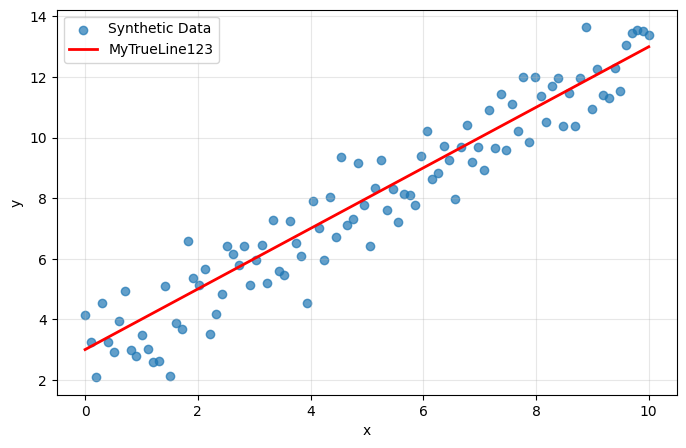

In [60]:
np.random.seed(67)

n = 100
x = np.linspace(0, 10, n)
true_slope = 1.0
true_intercept = 3.0
noise = np.random.normal(loc=0.0, scale=1.0, size=n)
y = true_slope * x + true_intercept + noise

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7, label='Synthetic Data')
plt.plot(x, true_slope * x + true_intercept, color='red', linewidth=2, label='MyTrueLine123')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Тепер реалізуємо функцію, яка буде рахувати RSS.

*Завдання №2:*
1. Реалізуйте функцію для обчислення residual sum of squares (RSS).
2. Перевірте її на прикладі довільних значень y_true та y_pred.

In [61]:
def rss(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sum((y_true - y_pred) ** 2)

y_true = np.array([3.0, 5.0, 7.0, 9.0])
y_pred = np.array([2.5, 5.5, 6.0, 10.0])

rss_value = rss(y_true, y_pred)
print(f"RSS: {rss_value}")

RSS: 2.5


Тепер реалізуємо функцію, яка буде рахувати похідну від RSS по b

*Завдання №3:*
1. Реалізуйте функцію для обчислення похідної від RSS по intersept(b).
2. Перевірте її на прикладі довільних значень y_true та y_pred.

In [41]:
def rss_deriv_b(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return -2 * np.sum(y_true - y_pred)

y_true = np.array([3.0, 5.0, 7.0, 9.0])
y_pred = np.array([2.5, 5.5, 6.0, 10.0])

grad_b = rss_deriv_b(y_true, y_pred)
print(f"dRSS/db: {grad_b}")

dRSS/db: -0.0


Тепер найголовніше - функція, яка буде змінювати значення b допоки не буде досягнуто достатньої наближеності

*Завдання №4:*
1. Реалізуйте градієнтний спуск для оптимізації intercept.
2. Виведіть значення втрат та intercept на кожній десятій ітерації.
3. Збережіть історію втрат для подальшої візуалізації.

In [42]:
fixed_slope = 1.0
b = 0.0
learning_rate = 0.001
step_tolerance = 1e-7
step_size = float('inf')
loss_history = []
intercept_history = []

epoch = 0
while step_size >= step_tolerance:
    epoch += 1

    y_pred = fixed_slope * x + b
    loss = rss(y, y_pred)
    grad_b = rss_deriv_b(y, y_pred)

    step_size = learning_rate * grad_b
    b = b - step_size
    step_size = abs(step_size)

    loss_history.append(loss)
    intercept_history.append(b)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:4d} | RSS: {loss:.4f} | intercept (b): {b:.6f} | step: {step_size:.10f}")

    if step_size < step_tolerance:
        print(f"Converged at epoch {epoch}: step_size={step_size:.10f} < {step_tolerance}")

final_intercept = b
y_pred_final = fixed_slope * x + final_intercept
print(f"\nFinal intercept: {final_intercept:.6f}")
print(f"Final RSS: {rss(y, y_pred_final):.6f}")

Epoch   10 | RSS: 98.6900 | intercept (b): 2.527947 | step: 0.0760218317
Epoch   20 | RSS: 84.4083 | intercept (b): 2.799383 | step: 0.0081627820
Epoch   30 | RSS: 84.2436 | intercept (b): 2.828528 | step: 0.0008764720
Epoch   40 | RSS: 84.2417 | intercept (b): 2.831657 | step: 0.0000941105
Epoch   50 | RSS: 84.2417 | intercept (b): 2.831993 | step: 0.0000101050
Epoch   60 | RSS: 84.2417 | intercept (b): 2.832030 | step: 0.0000010850
Epoch   70 | RSS: 84.2417 | intercept (b): 2.832033 | step: 0.0000001165
Converged at epoch 71: step_size=0.0000000932 < 1e-07

Final intercept: 2.832034
Final RSS: 84.241706


Тепер потрібно побудувати 2 графіки - один залежність похибки від ітерації, інший - це лінія регресії з новим b та точки

*Завдання №5:*
1. Побудуйте графік зміни функції втрат під час навчання.
2. Проаналізуйте, чи збігається процес навчання до мінімуму.
3. Намалюйте графік лінійної регресії

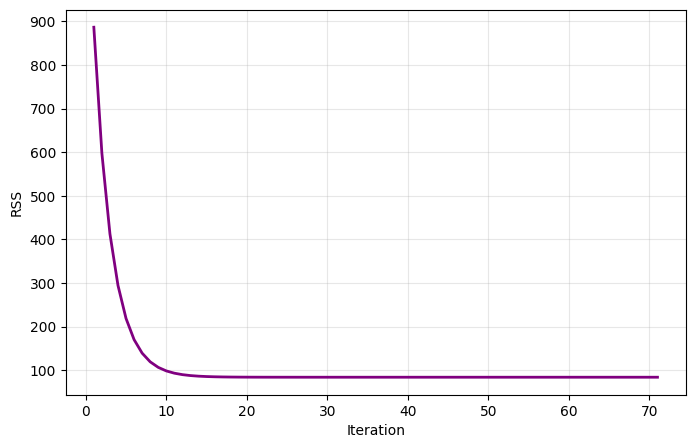

Процес навчання збігається, RSS зменшується.


In [47]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history) + 1), loss_history, color='purple', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('RSS')
plt.grid(alpha=0.3)
plt.show()

if len(loss_history) > 1 and loss_history[-1] <= loss_history[-2]:
    print('Процес навчання збігається, RSS зменшується.')
else:
    print('Else')

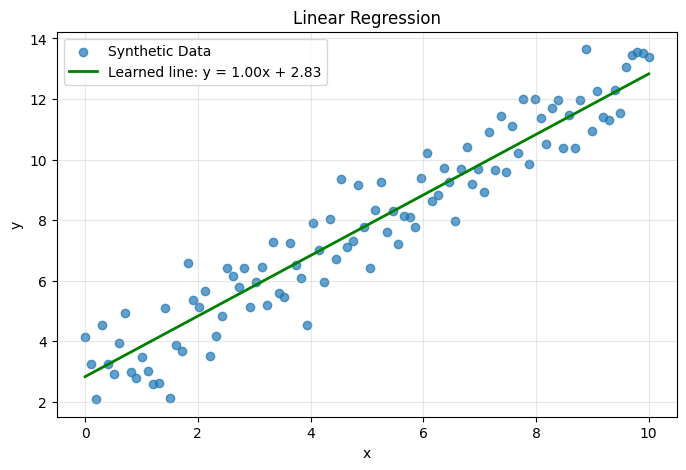

In [48]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7, label='Synthetic Data')
plt.plot(x, y_pred_final, color='green', linewidth=2, label=f'Learned line: y = {fixed_slope:.2f}x + {final_intercept:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Part 2

В цій частині ми будемо оптимізовувати вже 2 змінні і відповідно брати похідну по 2 змінним.

Тому спочатку потрібно написати функцію, яка шукає градієнт - 2 похідних по k(slope) та по b(intercept)

*Завдання №1:*
- Реалізуйте функції для обчислення градієнтів функції втрат по intercept та slope.
- Перевірте їх на прикладі довільних значень y_true та y_pred.

In [62]:
def grad_intercept(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return -2 * np.sum(y_true - y_pred)

def grad_slope(x, y_true, y_pred):
    x = np.asarray(x)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return -2 * np.sum(x * (y_true - y_pred))

x_test = np.array([1.0, 2.0, 3.0, 4.0])
y_true_test = np.array([3.0, 5.0, 7.0, 9.0])
y_pred_test = np.array([2.6, 5.4, 6.2, 9.5])

db = grad_intercept(y_true_test, y_pred_test)
dk = grad_slope(x_test, y_true_test, y_pred_test)

print(f"dRSS/db (intercept): {db}")
print(f"dRSS/dk (slope): {dk}")

dRSS/db (intercept): -0.5999999999999988
dRSS/dk (slope): 2.6645352591003757e-15


Тепер потрібно модифікувати функцію градієнтного спуску під 2 змінні

*Завдання №2:*
1. Реалізуйте градієнтний спуск для оптимізації intercept та slope.
2. Виведіть значення втрат та параметрів на кожній ітерації.
3. Збережіть історію втрат для подальшої візуалізації.

In [63]:
k = 0.0
b = 0.0
learning_rate = 0.01
step_tolerance = 1e-7
max_epochs = 10000
n_samples = len(x)

loss_history_part2 = []
slope_history = []
intercept_history_part2 = []

for epoch in range(1, max_epochs + 1):
    y_pred = k * x + b
    loss = rss(y, y_pred)

    db = grad_intercept(y, y_pred) / n_samples
    dk = grad_slope(x, y, y_pred) / n_samples

    step_b = learning_rate * db
    step_k = learning_rate * dk

    b = b - step_b
    k = k - step_k

    loss_history_part2.append(loss)
    slope_history.append(k)
    intercept_history_part2.append(b)

    print(f"Epoch {epoch:4d} | RSS: {loss:.6f} | slope (k): {k:.6f} | intercept (b): {b:.6f}")

    if max(abs(step_k), abs(step_b)) < step_tolerance:
        print(f"Converged at epoch {epoch}: max_step={max(abs(step_k), abs(step_b)):.10f}")
        break
else:
    print(f"Reached max_epochs={max_epochs}")
final_slope_part2 = k
final_intercept_part2 = b
y_pred_part2 = final_slope_part2 * x + final_intercept_part2

print(f"\nFinal slope: {final_slope_part2:.6f}")
print(f"Final intercept: {final_intercept_part2:.6f}")
print(f"Final RSS: {rss(y, y_pred_part2):.6f}")

Epoch    1 | RSS: 7121.530898 | slope (k): 0.958542 | intercept (b): 0.156641
Epoch    2 | RSS: 918.889589 | slope (k): 1.259164 | intercept (b): 0.214294
Epoch    3 | RSS: 302.343809 | slope (k): 1.352594 | intercept (b): 0.240733
Epoch    4 | RSS: 239.846612 | slope (k): 1.380779 | intercept (b): 0.257299
Epoch    5 | RSS: 232.313909 | slope (k): 1.388422 | intercept (b): 0.270716
Epoch    6 | RSS: 230.245857 | slope (k): 1.389603 | intercept (b): 0.283100
Epoch    7 | RSS: 228.732878 | slope (k): 1.388754 | intercept (b): 0.295119
Epoch    8 | RSS: 227.287903 | slope (k): 1.387272 | intercept (b): 0.306982
Epoch    9 | RSS: 225.862497 | slope (k): 1.385596 | intercept (b): 0.318756
Epoch   10 | RSS: 224.451729 | slope (k): 1.383866 | intercept (b): 0.330462
Epoch   11 | RSS: 223.054984 | slope (k): 1.382125 | intercept (b): 0.342106
Epoch   12 | RSS: 221.672077 | slope (k): 1.380386 | intercept (b): 0.353692
Epoch   13 | RSS: 220.302865 | slope (k): 1.378653 | intercept (b): 0.36522

Знову малюємо графіки і порівнюємо результати

*Завдання №3:*
1. Намалюйте 2 графіки як в минулому завданні і порівняєте результати

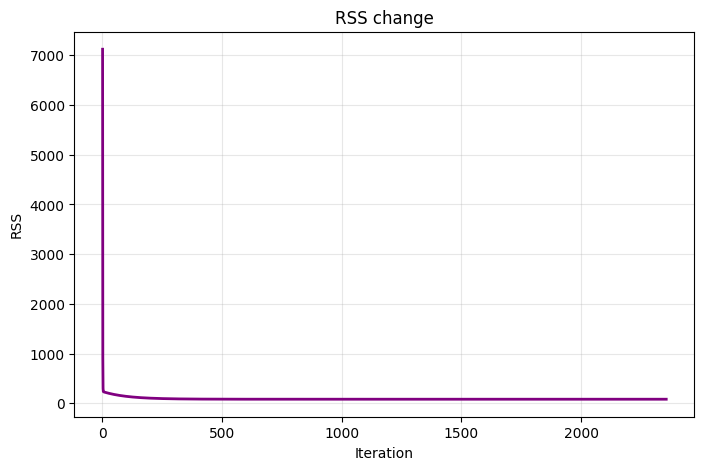

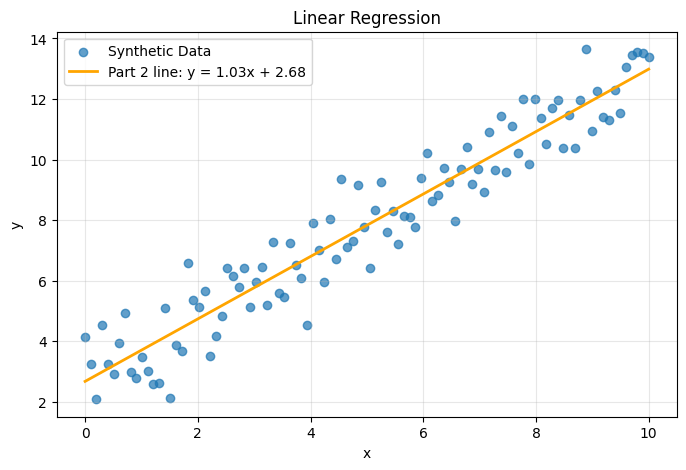

RSS Part 1 (only intercept): 84.241706
RSS Part 2 (slope + intercept): 83.414280
Висновок: Part 2 дає кращий результат


In [65]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(loss_history_part2) + 1), loss_history_part2, color='purple', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('RSS')
plt.title('RSS change')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7, label='Synthetic Data')
plt.plot(x, y_pred_part2, color='orange', linewidth=2, label=f'Part 2 line: y = {final_slope_part2:.2f}x + {final_intercept_part2:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

rss_part2 = rss(y, y_pred_part2)
if 'y_pred_final' in globals():
    rss_part1 = rss(y, y_pred_final)
    print(f'RSS Part 1 (only intercept): {rss_part1:.6f}')
    print(f'RSS Part 2 (slope + intercept): {rss_part2:.6f}')
    if rss_part2 < rss_part1:
        print('Висновок: Part 2 дає кращий результат')
    else:
        print('Висновок: покращення відсутнє')
else:
    print(f'RSS Part 2 (slope + intercept): {rss_part2:.6f}')

# Part 3

В цій частині ми побудуємо 3д графік графієнтного спуску. (Схожим чином як це показано у відео 3blue1brown)

Для початку імпортуємо необхідні бібліотеки

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

*Завдання №1:*
- Визначити функцію для обчислення середньоквадратичної помилки (MSE) для заданих значень intercept (зсув), slope (нахил), вхідних даних (X) та цільових значень (y).

In [83]:
def mse_loss(intercept, slope, X, y):
    X = np.asarray(X)
    y = np.asarray(y)
    y_pred = slope * X + intercept
    return np.mean((y - y_pred) ** 2)

# test
mse_example = mse_loss(intercept=0.0, slope=1.0, X=x, y=y)
print(f"MSE (intercept=0.0, slope=1.0): {mse_example:.6f}")

MSE (intercept=0.0, slope=1.0): 8.862833


*Завдання №2:*
- Створити сітку значень для intercept та slope, щоб оцінити функцію втрат для різних комбінацій параметрів. Це знадобиться для візуалізації поверхні втрат.

In [84]:
intercept_values = np.linspace(1.0, 4.5, 120)
slope_values = np.linspace(0.5, 1.5, 120)

slope_grid, intercept_grid = np.meshgrid(slope_values, intercept_values)

print(f"intercept grid shape: {intercept_grid.shape}")
print(f"slope grid shape: {slope_grid.shape}")

intercept grid shape: (120, 120)
slope grid shape: (120, 120)


*Завдання №3:*
- Написати функцію для обчислення значення втрат (MSE) для кожної комбінації intercept та slope у сітці. Ці значення будуть використані для побудови 3D-графіка поверхні втрат.

In [85]:
mse_surface = np.zeros_like(intercept_grid, dtype=float)

for i in range(intercept_grid.shape[0]):
    for j in range(intercept_grid.shape[1]):
        current_intercept = intercept_grid[i, j]
        current_slope = slope_grid[i, j]
        mse_surface[i, j] = mse_loss(current_intercept, current_slope, x, y)

print(f"mse_surface shape: {mse_surface.shape}")
print(f"min MSE on grid: {mse_surface.min():.6f}")
print(f"max MSE on grid: {mse_surface.max():.6f}")

mse_surface shape: (120, 120)
min MSE on grid: 0.834242
max MSE on grid: 21.999582


Завдання №4:
- Переписати алгоритм градієнтного спуску для оптимізації intercept та slope
- Зберігати історію значень intercept, slope та втрат на кожній епосі для подальшої візуалізації.

In [88]:
gd_intercept = 0.0
gd_slope = 0.0
gd_learning_rate = 0.01
gd_step_tolerance = 1e-7
gd_max_epochs = 5000
n_samples = len(x)

gd_intercept_history = []
gd_slope_history = []
gd_loss_history = []

for epoch in range(1, gd_max_epochs + 1):
    y_pred = gd_slope * x + gd_intercept
    error = y - y_pred

    grad_intercept_mse = (-2 / n_samples) * np.sum(error)
    grad_slope_mse = (-2 / n_samples) * np.sum(x * error)

    step_intercept = gd_learning_rate * grad_intercept_mse
    step_slope = gd_learning_rate * grad_slope_mse

    gd_intercept = gd_intercept - step_intercept
    gd_slope = gd_slope - step_slope

    current_mse = mse_loss(gd_intercept, gd_slope, x, y)
    gd_intercept_history.append(gd_intercept)
    gd_slope_history.append(gd_slope)
    gd_loss_history.append(current_mse)

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | MSE: {current_mse:.6f} | slope: {gd_slope:.6f} | intercept: {gd_intercept:.6f}")

    if max(abs(step_intercept), abs(step_slope)) < gd_step_tolerance:
        print(f"Converged at epoch {epoch}: max_step={max(abs(step_intercept), abs(step_slope)):.10f}")
        break
else:
    print(f"Reached max_epochs={gd_max_epochs}")

gd_final_intercept = gd_intercept
gd_final_slope = gd_slope
gd_final_loss = gd_loss_history[-1]

print(f"\nFinal intercept: {gd_final_intercept:.6f}")
print(f"Final slope: {gd_final_slope:.6f}")
print(f"Final MSE: {gd_final_loss:.6f}")

Epoch  500 | MSE: 0.844785 | slope: 1.061986 | intercept: 2.471280
Epoch 1000 | MSE: 0.834216 | slope: 1.033754 | intercept: 2.659041
Epoch 1500 | MSE: 0.834143 | slope: 1.031409 | intercept: 2.674636
Epoch 2000 | MSE: 0.834143 | slope: 1.031215 | intercept: 2.675932
Converged at epoch 2356: max_step=0.0000000996

Final intercept: 2.676029
Final slope: 1.031200
Final MSE: 0.834143


*Завдання №5:*
- Візуалізувати поверхню функції втрат та траєкторію градієнтного спуску в 3D.

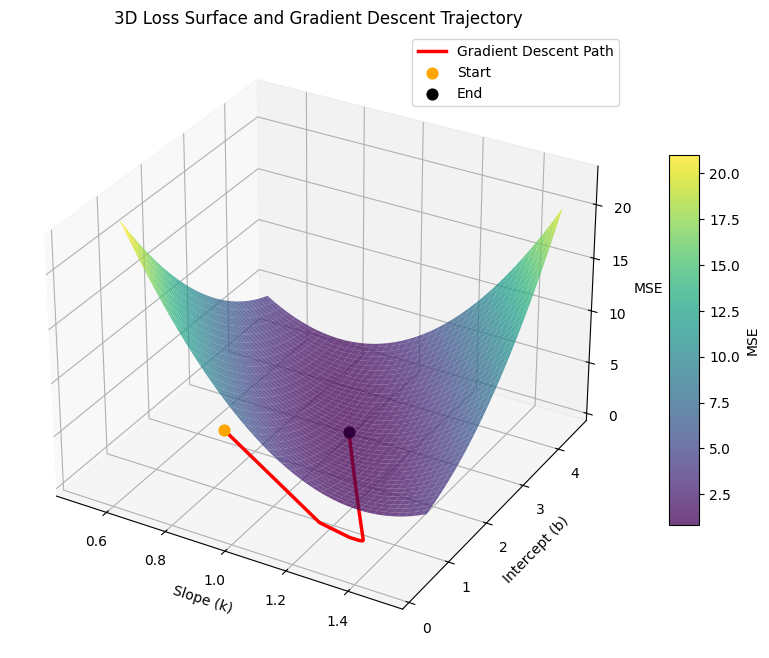

In [87]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    slope_grid,
    intercept_grid,
    mse_surface,
    cmap='viridis',
    alpha=0.75,
    linewidth=0,
    antialiased=True
)

ax.plot(
    gd_slope_history,
    gd_intercept_history,
    gd_loss_history,
    color='red',
    linewidth=2.5,
    label='Gradient Descent Path'
)

ax.scatter(
    gd_slope_history[0],
    gd_intercept_history[0],
    gd_loss_history[0],
    color='orange',
    s=60,
    label='Start'
)
ax.scatter(
    gd_slope_history[-1],
    gd_intercept_history[-1],
    gd_loss_history[-1],
    color='black',
    s=60,
    label='End'
)

ax.set_xlabel('Slope (k)')
ax.set_ylabel('Intercept (b)')
ax.set_zlabel('MSE')
ax.set_title('3D Loss Surface and Gradient Descent Trajectory')
fig.colorbar(surface, shrink=0.6, aspect=12, label='MSE')
ax.legend()
plt.show()